# Chương 3 — Phân tích dữ liệu khám phá (EDA)
**Đề tài:** Đánh giá nguy cơ mắc bệnh tim bằng ANN
**Người thực hiện:** Phạm Thế Đức — *Data Engineer & Data Analyst*

Notebook này khám phá bộ dữ liệu **Heart Disease** (Kaggle: `johnsmith88/heart-disease-dataset`):
thống kê mô tả, kiểm tra chất lượng dữ liệu, phân bố các đặc trưng và tương quan giữa chúng.
Kết quả ở đây dùng cho **Chương 3** của báo cáo.

In [1]:
# ===== Thư viện =====
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12

# ----- Tự xác định đường dẫn (chạy được dù mở từ gốc dự án hay từ thư mục notebook/) -----
def find_path(*cands):
    for c in cands:
        if os.path.exists(c):
            return c
    return cands[0]

RAW_PATH = find_path("data/raw/heart.csv", "../data/raw/heart.csv", "heart.csv")
FIG_DIR = "bao_cao/figures" if os.path.isdir("data") else "../bao_cao/figures"
os.makedirs(FIG_DIR, exist_ok=True)
print("Doc du lieu tu:", RAW_PATH)
print("Luu bieu do vao:", FIG_DIR)

Doc du lieu tu: ../data/raw/heart.csv
Luu bieu do vao: ../bao_cao/figures


## 1. Đọc dữ liệu & xem tổng quan

In [2]:
df = pd.read_csv(RAW_PATH)
print("Kich thuoc:", df.shape)
df.head()

Kich thuoc: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
# Kiểu dữ liệu của từng cột
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


**Ý nghĩa các cột (14 thuộc tính):**

| Cột | Ý nghĩa | Cột | Ý nghĩa |
|---|---|---|---|
| age | Tuổi | exang | Đau ngực khi gắng sức (1/0) |
| sex | Giới tính (1=nam, 0=nữ) | oldpeak | Chênh ST khi gắng sức |
| cp | Kiểu đau ngực (0–3) | slope | Độ dốc đoạn ST (0–2) |
| trestbps | Huyết áp lúc nghỉ (mm Hg) | ca | Số mạch lớn nhuộm màu (0–4) |
| chol | Cholesterol (mg/dl) | thal | Thalassemia (0–3) |
| fbs | Đường huyết đói >120 (1/0) | **target** | **1=có nguy cơ, 0=không** |
| restecg | Điện tâm đồ nghỉ (0–2) | thalach | Nhịp tim tối đa |

## 2. Kiểm tra chất lượng dữ liệu
Kiểm tra **giá trị thiếu**, **bản ghi trùng** và xử lý trước khi phân tích.

In [4]:
# 2.1 Giá trị thiếu
print("So o thieu theo cot:")
print(df.isnull().sum())
print("\nTong so o thieu:", int(df.isnull().sum().sum()))

So o thieu theo cot:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Tong so o thieu: 0


In [5]:
# 2.2 Bản ghi trùng lặp
n_dup = int(df.duplicated().sum())
print(f"So ban ghi trung lap hoan toan: {n_dup}")
print(f"So ban ghi duy nhat            : {df.drop_duplicates().shape[0]}")

So ban ghi trung lap hoan toan: 723
So ban ghi duy nhat            : 302


> **Nhận xét quan trọng:** Bộ dữ liệu có rất nhiều bản ghi **trùng lặp hoàn toàn**.
> Nếu giữ lại, cùng một bệnh nhân có thể rơi vào *cả* tập train lẫn test → **rò rỉ dữ liệu (data leakage)**
> làm độ chính xác bị "ảo". Vì vậy ta **loại bỏ trùng lặp** trước khi phân tích và huấn luyện.

In [6]:
# 2.3 Loại bỏ trùng lặp -> dữ liệu dùng cho EDA
df = df.drop_duplicates().reset_index(drop=True)
print("Kich thuoc sau khi loai trung:", df.shape)
print("\nPhan bo nhan target:")
print(df["target"].value_counts())

Kich thuoc sau khi loai trung: (302, 14)

Phan bo nhan target:
target
1    164
0    138
Name: count, dtype: int64


## 3. Thống kê mô tả

In [7]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,302.0,54.42,9.05,29.0,48.00,55.5,61.00,77.0
sex,302.0,0.68,0.47,0.0,0.00,1.0,1.00,1.0
cp,302.0,0.96,1.03,0.0,0.00,1.0,2.00,3.0
trestbps,302.0,131.60,17.56,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.50,51.75,126.0,211.00,240.5,274.75,564.0
fbs,302.0,0.15,0.36,0.0,0.00,0.0,0.00,1.0
restecg,302.0,0.53,0.53,0.0,0.00,1.0,1.00,2.0
thalach,302.0,149.57,22.90,71.0,133.25,152.5,166.00,202.0
exang,302.0,0.33,0.47,0.0,0.00,0.0,1.00,1.0
oldpeak,302.0,1.04,1.16,0.0,0.00,0.8,1.60,6.2


## 4. Phân bố biến mục tiêu (target)

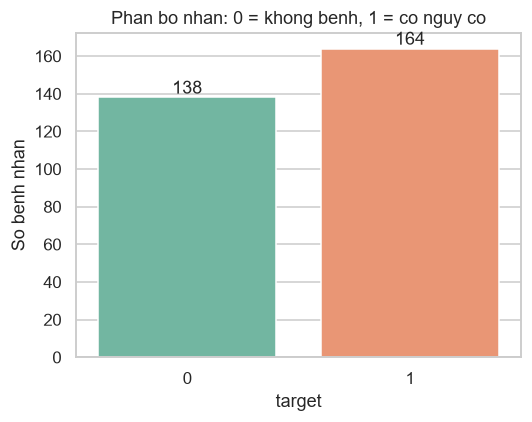

In [8]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(data=df, x="target", hue="target", palette="Set2", legend=False)
ax.set_title("Phan bo nhan: 0 = khong benh, 1 = co nguy co")
ax.set_xlabel("target"); ax.set_ylabel("So benh nhan")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/target_distribution.png", bbox_inches="tight")
plt.show()

## 5. Phân bố độ tuổi (age)

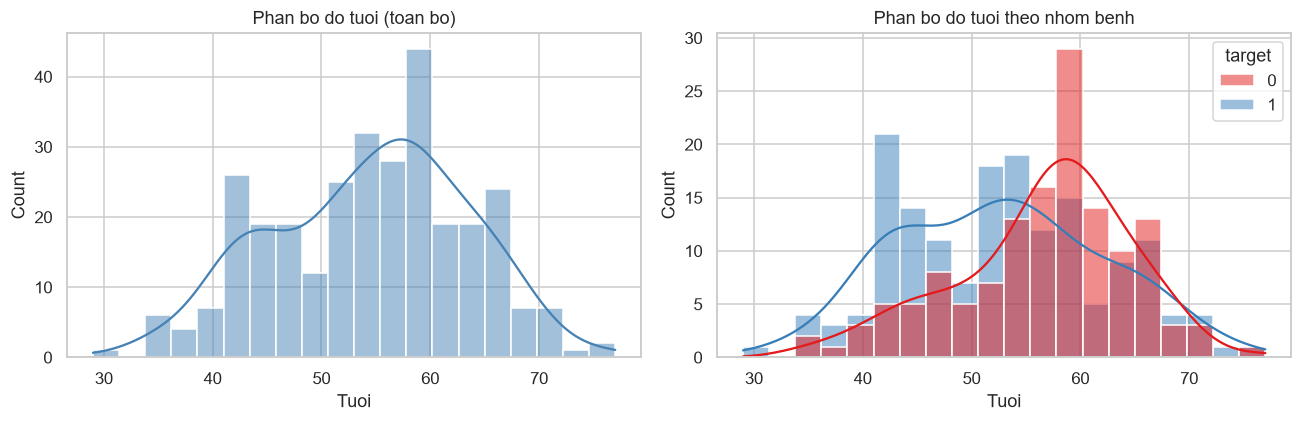

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["age"], kde=True, bins=20, color="steelblue", ax=axes[0])
axes[0].set_title("Phan bo do tuoi (toan bo)")
axes[0].set_xlabel("Tuoi")

sns.histplot(data=df, x="age", hue="target", bins=20, kde=True,
             palette="Set1", ax=axes[1])
axes[1].set_title("Phan bo do tuoi theo nhom benh")
axes[1].set_xlabel("Tuoi")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/age_distribution.png", bbox_inches="tight")
plt.show()

## 6. Phân tích giới tính (sex)

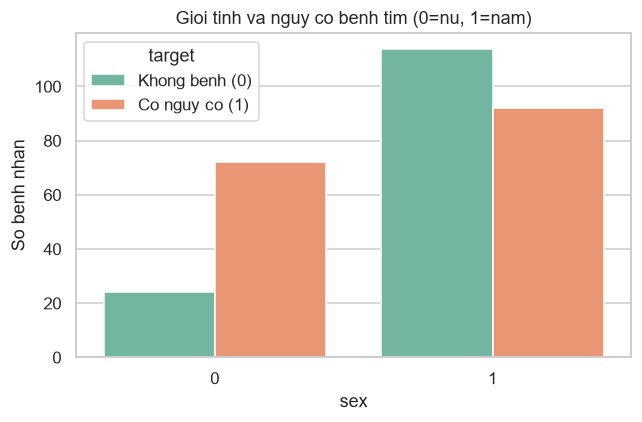

In [10]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="sex", hue="target", palette="Set2")
ax.set_title("Gioi tinh va nguy co benh tim (0=nu, 1=nam)")
ax.set_xlabel("sex"); ax.set_ylabel("So benh nhan")
ax.legend(title="target", labels=["Khong benh (0)", "Co nguy co (1)"])
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/sex_vs_target.png", bbox_inches="tight")
plt.show()

## 7. Các đặc trưng liên tục: huyết áp, cholesterol, nhịp tim, oldpeak
Dùng **Histogram** để xem phân bố và **Boxplot** để soi giá trị ngoại lệ (outlier).

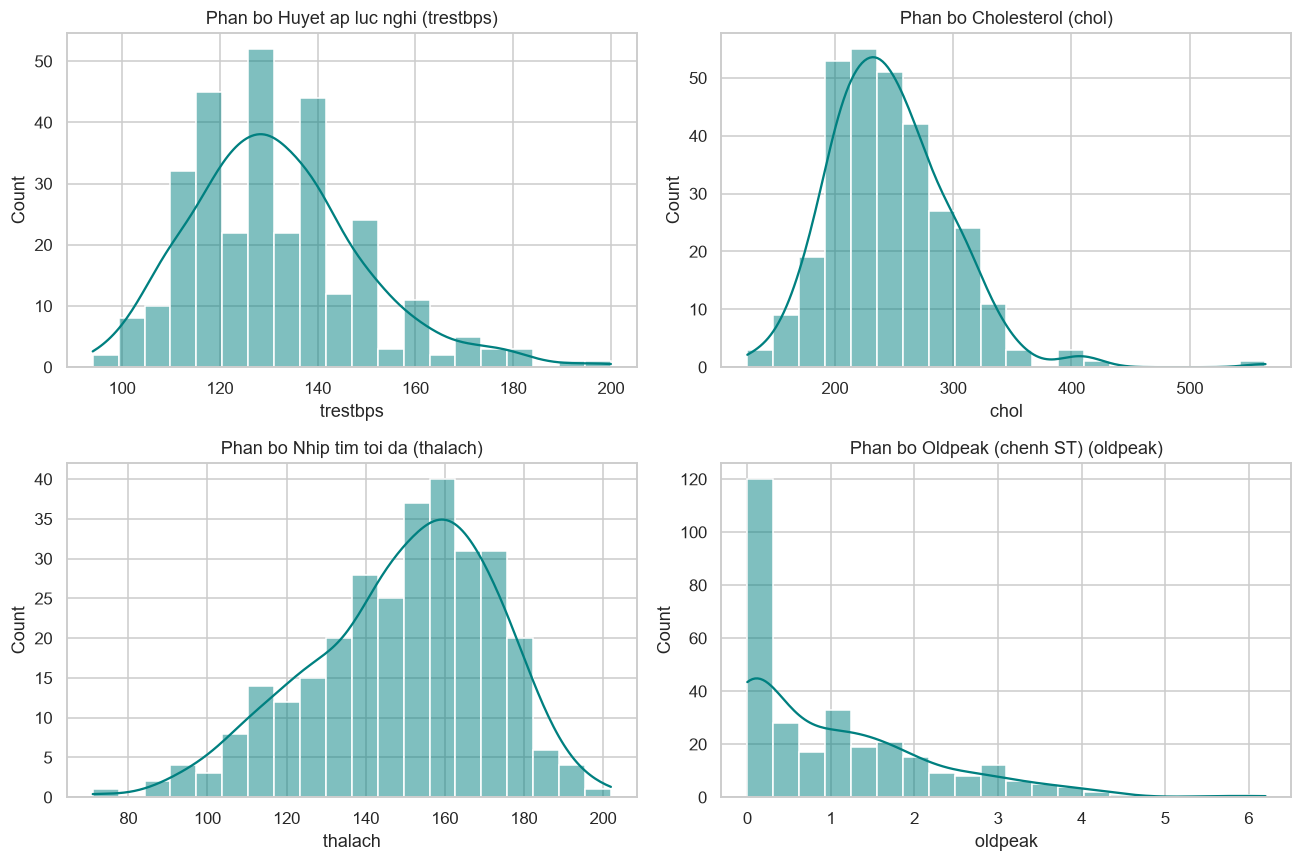

In [11]:
cont_cols = ["trestbps", "chol", "thalach", "oldpeak"]
titles = ["Huyet ap luc nghi", "Cholesterol", "Nhip tim toi da", "Oldpeak (chenh ST)"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col, t in zip(axes.ravel(), cont_cols, titles):
    sns.histplot(df[col], kde=True, bins=20, color="teal", ax=ax)
    ax.set_title(f"Phan bo {t} ({col})")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/continuous_histograms.png", bbox_inches="tight")
plt.show()

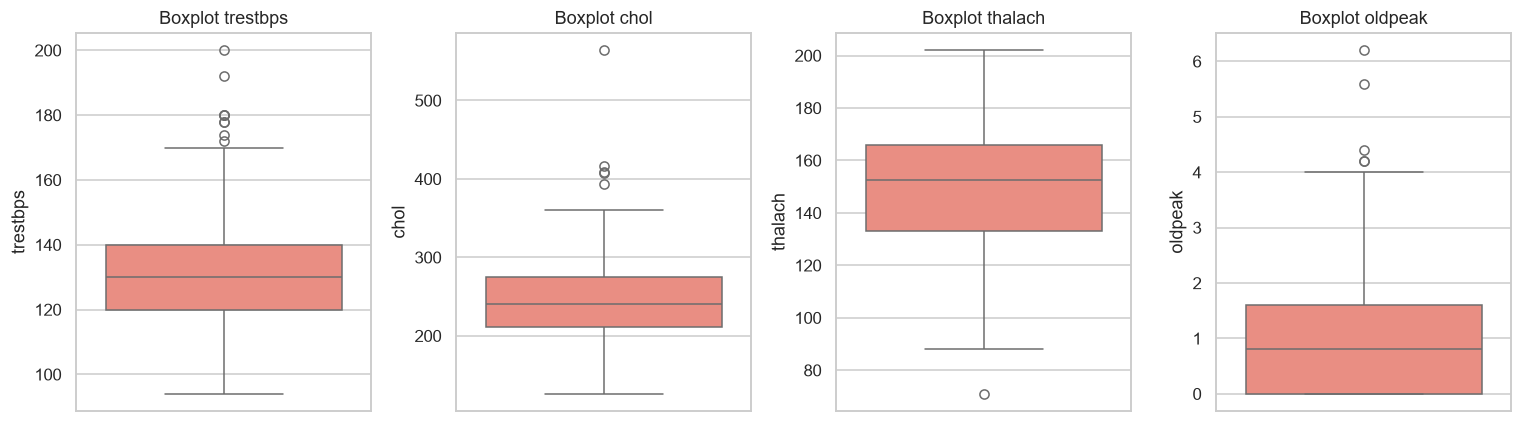

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, cont_cols):
    sns.boxplot(data=df, y=col, color="salmon", ax=ax)
    ax.set_title(f"Boxplot {col}")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/continuous_boxplots.png", bbox_inches="tight")
plt.show()

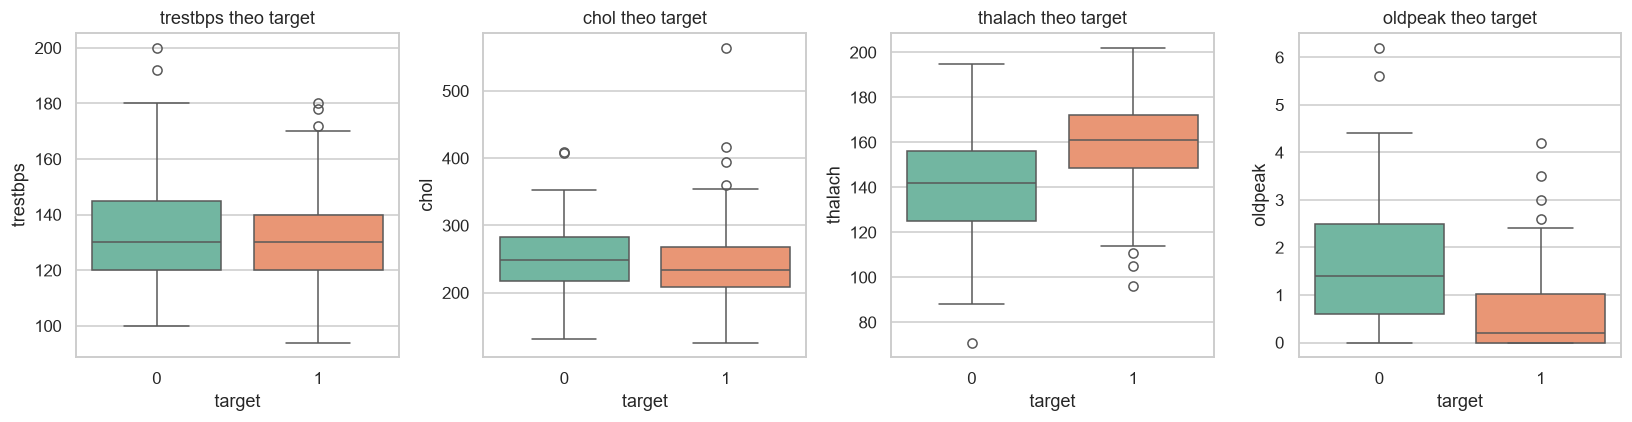

In [13]:
# So sánh phân bố đặc trưng liên tục giữa 2 nhóm benh (boxplot theo target)
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, col in zip(axes, cont_cols):
    sns.boxplot(data=df, x="target", y=col, hue="target",
                palette="Set2", legend=False, ax=ax)
    ax.set_title(f"{col} theo target")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/continuous_by_target.png", bbox_inches="tight")
plt.show()

## 8. Đường huyết (fbs) & các biến phân loại

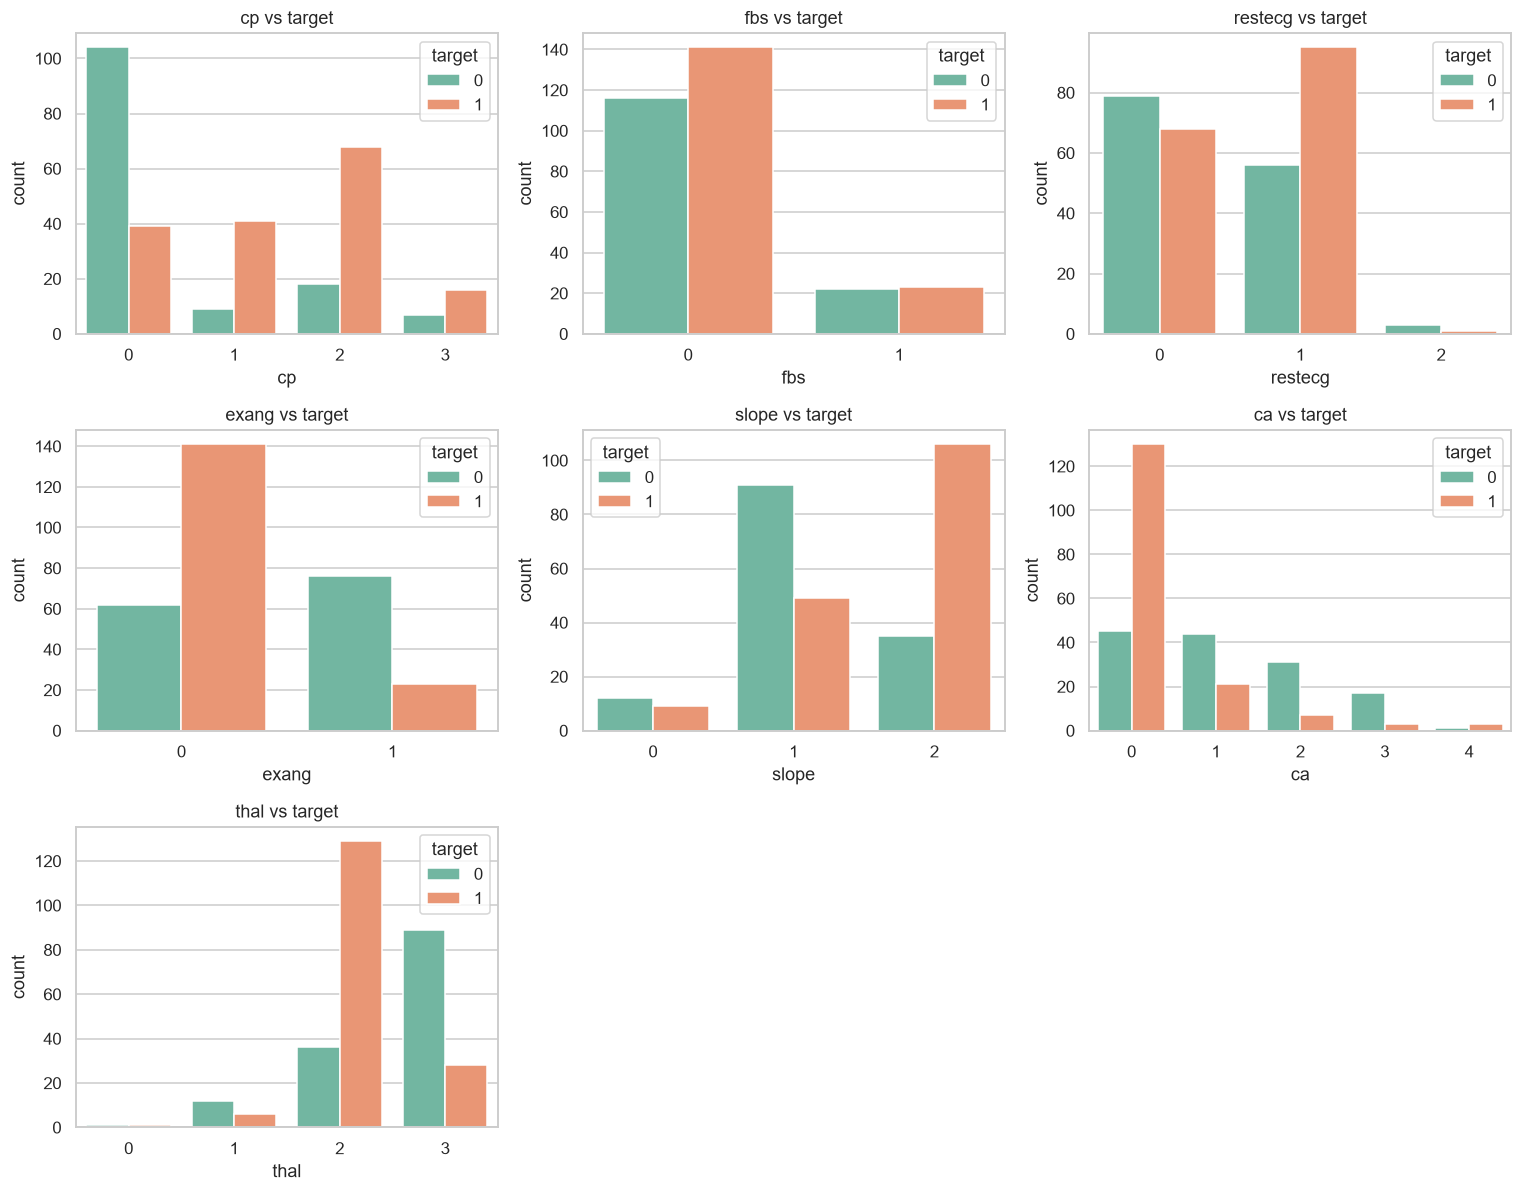

In [14]:
cat_cols = ["cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
for ax, col in zip(axes.ravel(), cat_cols):
    sns.countplot(data=df, x=col, hue="target", palette="Set2", ax=ax)
    ax.set_title(f"{col} vs target")
# Tat cac o thua
for ax in axes.ravel()[len(cat_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/categorical_countplots.png", bbox_inches="tight")
plt.show()

## 9. Ma trận tương quan (Correlation Heatmap)

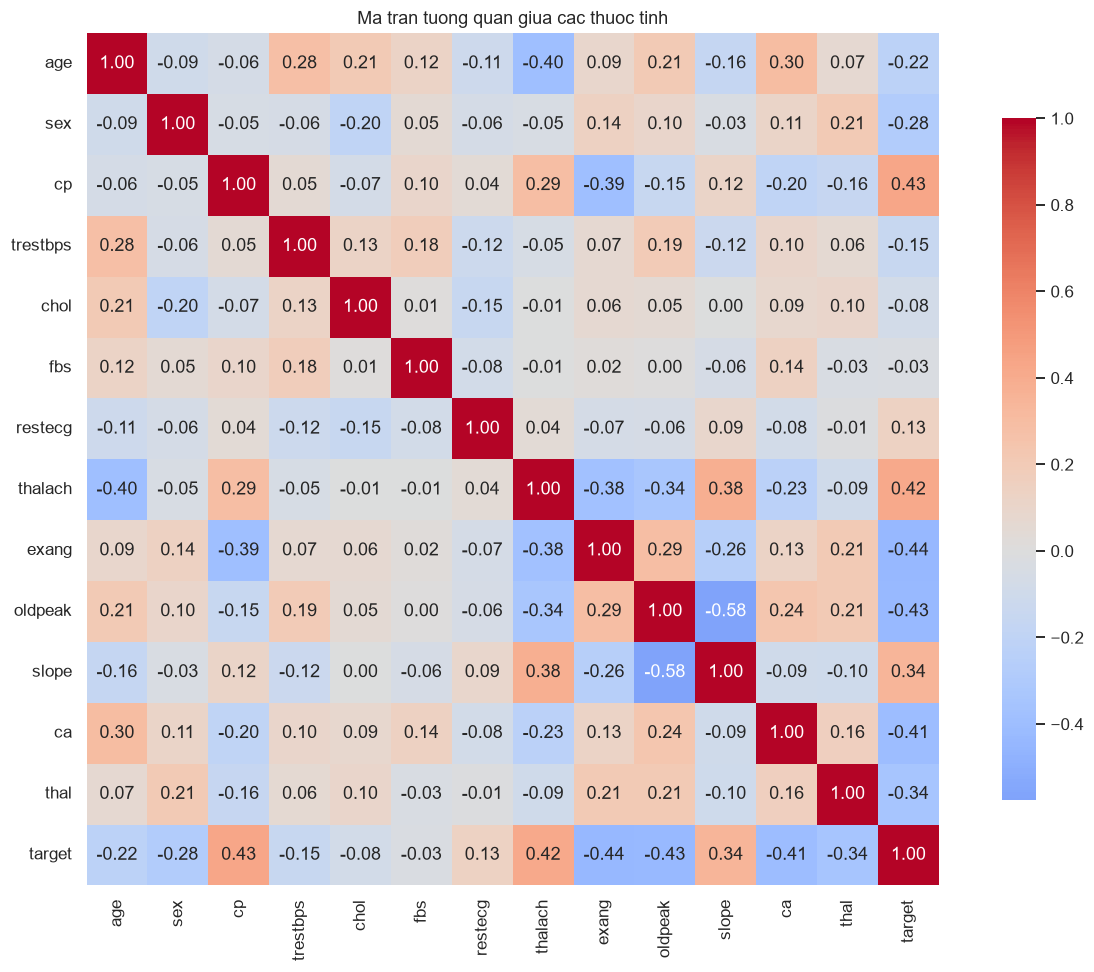

In [15]:
plt.figure(figsize=(12, 9))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Ma tran tuong quan giua cac thuoc tinh")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/correlation_heatmap.png", bbox_inches="tight")
plt.show()

In [16]:
# Top thuộc tính tương quan mạnh nhất với target
corr_target = df.corr(numeric_only=True)["target"].drop("target").sort_values(key=abs, ascending=False)
print("Tuong quan cua tung thuoc tinh voi 'target' (sap xep theo do lon):")
print(corr_target.round(3))

Tuong quan cua tung thuoc tinh voi 'target' (sap xep theo do lon):
exang      -0.436
cp          0.432
oldpeak    -0.429
thalach     0.420
ca         -0.409
slope       0.344
thal       -0.343
sex        -0.284
age        -0.221
trestbps   -0.146
restecg     0.135
chol       -0.081
fbs        -0.027
Name: target, dtype: float64


## 10. Nhận xét tổng hợp (phục vụ viết Chương 3)

- **Quy mô dữ liệu:** 1025 bản ghi nhưng có 723 bản trùng → còn **302 bản ghi duy nhất**.
  Việc loại trùng là bắt buộc để tránh rò rỉ dữ liệu giữa train/test.
- **Không có giá trị thiếu.** Nhãn `target` khá **cân bằng** giữa hai lớp.
- **Tương quan với nguy cơ bệnh:** các thuộc tính `cp` (kiểu đau ngực), `thalach` (nhịp tim tối đa),
  `oldpeak`, `exang`, `ca`, `thal` thường có tương quan mạnh nhất với `target`.
- **Đặc trưng liên tục** (`age, trestbps, chol, thalach, oldpeak`) có thang đo rất khác nhau
  → cần **chuẩn hoá (StandardScaler)** ở bước Feature Engineering.
- **Biến phân loại** (`cp, restecg, slope, ca, thal`) ở dạng số nguyên rời rạc; `ca` và `thal`
  có vài giá trị bất thường (ca=4, thal=0) — giữ lại như một mức riêng.

> Các bước làm sạch & chuẩn hoá tương ứng được cài đặt trong
> `src/data_preprocessing.py` và `src/feature_engineering.py`.